In [1]:
# Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import run_fair

import utils_MLP

from bayes_opt import BayesianOptimization
from scipy import signal

import seaborn as sns
from cmcrameri import cm

## Setup plots
plt.rcParams['figure.figsize'] = [12, 4]
plt.rcParams.update({'font.size': 16})
plt.rcParams.update({
  "text.usetex": True,
  "font.family": "sans-serif",
  "font.sans-serif": ["Helvetica Light"],
})

%load_ext autoreload
%autoreload 2

In [2]:
start, stop = 1750, 2500
years = np.arange(start, stop)
n_steps = len(years)

FS = 1

emis_dict_valid = run_fair.load_cmip7_extensions(n_steps, ['CO2'])

# Idealized pulse
pulse = np.zeros(n_steps)
pulse[0] = 5000 # Pulse magnitude
emis_dict_valid['pulse'] = run_fair.ensure_all_agents({'CO2': pulse}, n_steps)

# Idealized step (similar to 4xCO2)
step = np.zeros(n_steps)
year_step = 50
step[year_step:] = 10 # Step magnitude
emis_dict_valid['step'] = run_fair.ensure_all_agents({'CO2': step}, n_steps)

scenarios_valid = list(emis_dict_valid.keys())
delT_dict_valid = {}

agents = ['CO2','CH4','N2O','Sulfur','BC']
agents_lim = ['CO2']

for scen in scenarios_valid:
  # Use a fresh FaIR instance for each scenario to prevent state carryover
  f = run_fair.build_fair(start, stop)
  emis = {a: np.zeros(n_steps) for a in agents}
  for agent in agents_lim:
    emis[agent] = emis_dict_valid[scen][agent]

  run_fair.set_emissions(f, years, emis)
  _, _, T_mean, _ = run_fair.run_fair(f, years)
  delT_dict_valid[scen] = T_mean

# Format validation data
valid_series = []
for scen in scenarios_valid:
  valid_series.append(
    (emis_dict_valid[scen], delT_dict_valid[scen])
  )

In [11]:
def zero_mean(t, offset):
    """A mean trend with an offset."""
    return np.zeros_like(t) + offset

def sinusoidal_cycle(t, amplitude, frequency):
    """A long-period sinusoidal cycle."""
    return amplitude * np.sin(2 * np.pi * frequency * t)

def sine_sweep(t, amplitude, f0, f1):
    """A sinusoidal sweep across multiple frequencies"""
    return amplitude * signal.chirp(t, f0, n_steps, f1)

eps = 1e-7
MEAN_FUNCTIONS = {
    "const": {"function": zero_mean,
             "params": {"m_param_offset": (0.0, 20.0)}},
    "sinusoid": {
        "function": sinusoidal_cycle,
        "params": {"m_param_amplitude": (10.0, 75.0),
                   "m_param_frequency": (0.0005, 0.005)}, # 2,000 to 200 years
    },
    "sweep":{
        "function": sine_sweep,
        "params": {"m_param_amplitude": (10.0, 75.0),
                   "m_param_f0": (0.0005, 0.005 - eps), # 2,000 to 200 years
                   "m_param_f1": (0.005 + eps, 0.25)}   # 200 to 4 years
    }
}

mean = 'sinusoid'
CONFIG = {
    "CHOSEN_MEAN_FUNCTION": mean,
    "N_INNER_SAMPLES": 5,  # Stochastic samples per evaluation
    "NOISE_PARAM_SPACE": {
        "sigma": (50.0, 150.0),
        "f_low": (0.01, 0.1 - eps),
        "f_high": (0.1 + eps, 0.25),
    },
}
agents = ['CO2']
def evaluate_parameter_set(params, mean_func):
    """
    Evaluates a single, complete set of parameters by sampling N times.
    (This is your function, slightly modified to use CONFIG for N_INNER_SAMPLES)
    """
    nrmse_scores = []
    sigma, f_low, f_high = params['sigma'], params['f_low'], params['f_high']
    mean_func_params = {k.replace('m_param_', ''): v for k, v in params.items() if k.startswith('m_param_')}

    for _ in range(CONFIG["N_INNER_SAMPLES"]):
        m_t = mean_func(np.arange(n_steps), **mean_func_params)
        white_noise = np.random.randn(n_steps)
        nyquist = 0.5 * FS
        b, a = signal.butter(4, [f_low/nyquist, f_high/nyquist], btype='band')
        w_t = signal.filtfilt(b, a, white_noise)
        w_t -= np.mean(w_t)
        w_t /= np.std(w_t)
        u_t = m_t + sigma * w_t

        f_train = run_fair.build_fair(start, stop)
        emis_train = {'CO2': u_t}
        run_fair.set_emissions(f_train, years, run_fair.ensure_all_agents(emis_train, n_steps))
        f_train.run(progress=False)
        _, _, training_temp, _ = run_fair.run_fair(f_train, years)

        train_scenarios = ["bo_training_run"]
        train_series = [(emis_train, training_temp)]

        error_dict, _ = utils_MLP.evaluate_trainsets_vs_tests(
            train_scenarios, train_series, scenarios_valid, valid_series, agents
        )
        scores_for_this_run = [err for err in error_dict["bo_training_run"].values()]
        nrmse_scores.append(np.mean(scores_for_this_run))

    return np.mean(nrmse_scores)


# --- Bayesian Optimization Integration ---
# 1. Pre-select the mean function and build the parameter bounds
chosen_config = MEAN_FUNCTIONS[CONFIG["CHOSEN_MEAN_FUNCTION"]]
mean_function_to_run = chosen_config["function"]

pbounds = {**CONFIG["NOISE_PARAM_SPACE"], **chosen_config["params"]}

print(f"Starting Bayesian Optimization...")
print(f"Mean Function: '{CONFIG['CHOSEN_MEAN_FUNCTION']}'")
print(f"Stochastic Samples per Evaluation: {CONFIG['N_INNER_SAMPLES']}")
print(f"Optimizing over parameters: {list(pbounds.keys())}\n")

# 2. Define the black-box function for the optimizer
def black_box_for_bo(**params):
    """
    Wrapper function that takes keyword arguments from the optimizer,
    calls the evaluation function, and returns the value to be maximized.
    """
    mean_nrmse = evaluate_parameter_set(params, mean_function_to_run)

    # Return the negative of the NRMSE (optimizer maximizes)
    return -mean_nrmse

# 3. Instantiate and run the optimizer
optimizer = BayesianOptimization(
    f=black_box_for_bo,
    pbounds=pbounds,
    random_state=42, # for reproducibility
    verbose=1
)

for i in range(50):
    next_point = optimizer.suggest()
    target = black_box_for_bo(**next_point)
    optimizer.register(params=next_point, target=target)

    if i % 5 == 0:
        optimizer.save_state(f'data/Optimization/opt_FaIR_co2-only_m={mean}.json')

print(optimizer.max)

Starting Bayesian Optimization...
Mean Function: 'sinusoid'
Stochastic Samples per Evaluation: 5
Optimizing over parameters: ['sigma', 'f_low', 'f_high', 'm_param_amplitude', 'm_param_frequency']

| 2         | -0.424252 | 52.058449 | 0.0897465 | 0.1621715 | 38.305946 | 0.0045828 |
| 4         | -0.155287 | 127.56384 | 0.0229331 | 0.1548358 | 41.808049 | 0.0041508 |
| 8         | -0.106978 | 105.89802 | 0.0347645 | 0.1090713 | 44.567904 | 0.0038918 |


/Users/chriswomack/anaconda3/envs/research/lib/python3.13/site-packages/fair/gas_cycle/ch4_lifetime.py:73: RuntimeWarning: invalid value encountered in log
  + np.log(1 + temperature * ch4_lifetime_temperature_sensitivity)
/Users/chriswomack/anaconda3/envs/research/lib/python3.13/site-packages/fair/gas_cycle/ch4_lifetime.py:73: RuntimeWarning: invalid value encountered in log
  + np.log(1 + temperature * ch4_lifetime_temperature_sensitivity)
/Users/chriswomack/anaconda3/envs/research/lib/python3.13/site-packages/fair/gas_cycle/ch4_lifetime.py:73: RuntimeWarning: invalid value encountered in log
  + np.log(1 + temperature * ch4_lifetime_temperature_sensitivity)
/Users/chriswomack/anaconda3/envs/research/lib/python3.13/site-packages/fair/gas_cycle/ch4_lifetime.py:73: RuntimeWarning: invalid value encountered in log
  + np.log(1 + temperature * ch4_lifetime_temperature_sensitivity)
/Users/chriswomack/anaconda3/envs/research/lib/python3.13/site-packages/fair/gas_cycle/ch4_lifetime.py:73: R

| 35        | -0.090605 | 112.90740 | 0.0878239 | 0.2156699 | 42.242954 | 0.0025653 |
{'target': np.float64(-0.09060555143193823), 'params': {'sigma': np.float64(112.90740581979588), 'f_low': np.float64(0.087823918519176), 'f_high': np.float64(0.21566995577841588), 'm_param_amplitude': np.float64(42.24295455490873), 'm_param_frequency': np.float64(0.002565399244219537)}}


In [13]:
# 4. Display the best results
print("\n" + "="*60)
print("Bayesian Optimization Complete")
print("="*60)

best_params = optimizer.max['params']
best_nrmse = -optimizer.max['target'] # Convert back to positive NRMSE

print(f"Best NRMSE found: {best_nrmse:.5f}")
print("\nCorresponding Parameters:")
for param, value in best_params.items():
  print(f"  - {param}: {value:.4f}")


Bayesian Optimization Complete
Best NRMSE found: 0.09061

Corresponding Parameters:
  - sigma: 112.9074
  - f_low: 0.0878
  - f_high: 0.2157
  - m_param_amplitude: 42.2430
  - m_param_frequency: 0.0026


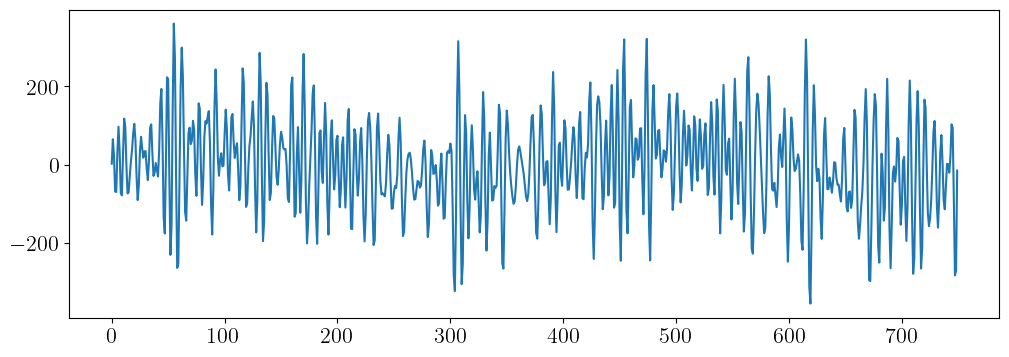

In [14]:
white_noise = np.random.randn(n_steps)
nyquist = 0.5 * FS
b, a = signal.butter(4, [best_params['f_low']/nyquist, best_params['f_high']/nyquist], btype='band')
w_t = signal.filtfilt(b, a, white_noise)
w_t -= np.mean(w_t)
w_t /= np.std(w_t)
noise_component = best_params['sigma'] * w_t

mean_func_params = {k.replace('m_param_', ''): v for k, v in best_params.items() if k.startswith('m_param_')}
m_t = mean_function_to_run(np.arange(n_steps), **mean_func_params)
u_t = m_t + noise_component

plt.plot(u_t)